#  Инициализация весов нейронных сетей. Способы регуляризации нейронных сетей. Продвинутые алгоритмы градиентного спуска.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.init.html
* https://machinelearningmastery.com/dropout-for-regularizing-deep-neural-networks/
* https://machinelearningmastery.com/batch-normalization-for-training-of-deep-neural-networks/
* https://pytorch.org/docs/stable/optim.html

## Задачи для совместного разбора

In [1]:
# Используемые библиотеки
import copy
import torch as th
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.init as init
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import load_diabetes
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
# Используемые библиотеки
import torch

1\. Инициализируйте веса полносвязного слоя единицами, а смещения - нулями.

In [3]:
class Linear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return torch.nn.functional.linear(x, self.weight, self.bias)

In [4]:
layer = Linear(10, 5); layer.weight, layer.bias

(Parameter containing:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], requires_grad=True),
 Parameter containing:
 tensor([0., 0., 0., 0., 0.], requires_grad=True))

2\. Изучите, как работает слой `nn.Dropout` в режиме обучения модели и в режиме использования модели.

In [5]:
dropout = nn.Dropout(p=0.5)

In [6]:
# Режим обучения
dropout.train(); dropout.training

True

In [7]:
x = torch.ones(10); x

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [8]:
output = dropout(x); output

tensor([0., 0., 0., 0., 0., 2., 0., 2., 0., 2.])

In [9]:
# Режим оценки
dropout.eval(); dropout.training

False

In [10]:
x_ = torch.ones(10); x_

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [11]:
output_ = dropout(x_); output_

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [12]:
class DropModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        return self.dropout(x)

In [13]:
model = DropModel()
x = torch.ones(20)

In [14]:
print("=== РЕЖИМ ОБУЧЕНИЯ ===")
model.train()
output_train = model(x)
print(f"Input sum: {x.sum().item()}")
print(f"Output sum: {output_train.sum().item()}")
print(f"Zeroed elements: {(output_train == 0).sum().item()}")

print("\n=== РЕЖИМ ИСПОЛЬЗОВАНИЯ ===")
model.eval()
output_eval = model(x)
print(f"Input sum: {x.sum().item()}")
print(f"Output sum: {output_eval.sum().item()}")
print(f"Zeroed elements: {(output_eval == 0).sum().item()}")

=== РЕЖИМ ОБУЧЕНИЯ ===
Input sum: 20.0
Output sum: 18.571430206298828
Zeroed elements: 7

=== РЕЖИМ ИСПОЛЬЗОВАНИЯ ===
Input sum: 20.0
Output sum: 20.0
Zeroed elements: 0


3\. Изучите, как работает слой `nn.BatchNorm1d` в режиме обучения модели и в режиме использования модели.

In [15]:
torch.manual_seed(42)
batch1 = torch.normal(5.0, 2.0, (32, 10))
batch2 = torch.normal(-3.0, 3.0, (32, 10))
batch3 = torch.normal(0.0, 4.0, (32, 10))

In [16]:
batchnorm = nn.BatchNorm1d(10)

In [17]:
batchnorm.train()
batch1_norm = batchnorm(batch1)
batch2_norm = batchnorm(batch2)
batch3_norm = batchnorm(batch3)

(-10.0, 10.0)

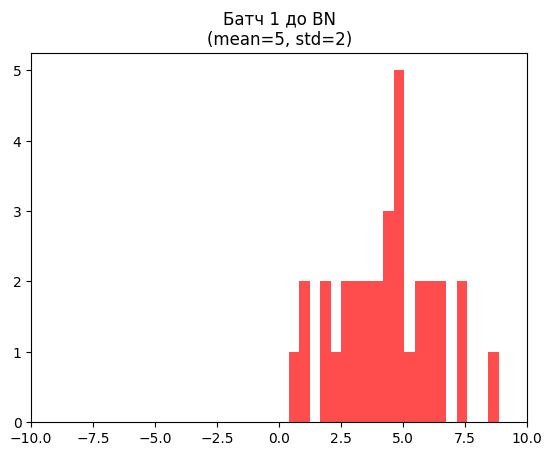

In [18]:
# ДО НОРМАЛИЗАЦИИ
plt.hist(batch1[:, 0].detach().numpy(), bins=20, alpha=0.7, color='red')
plt.title('Батч 1 до BN\n(mean=5, std=2)')
plt.xlim(-10, 10)

(-4.0, 4.0)

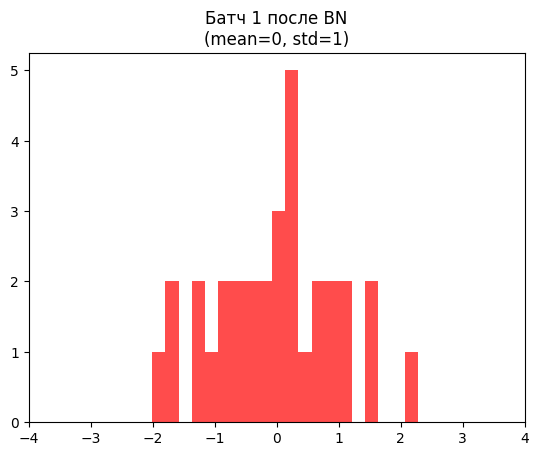

In [19]:
# ПОСЛЕ НОРМАЛИЗАЦИИ
plt.hist(batch1_norm[:, 0].detach().numpy(), bins=20, alpha=0.7, color='red')
plt.title('Батч 1 после BN\n(mean=0, std=1)')
plt.xlim(-4, 4)

(-10.0, 10.0)

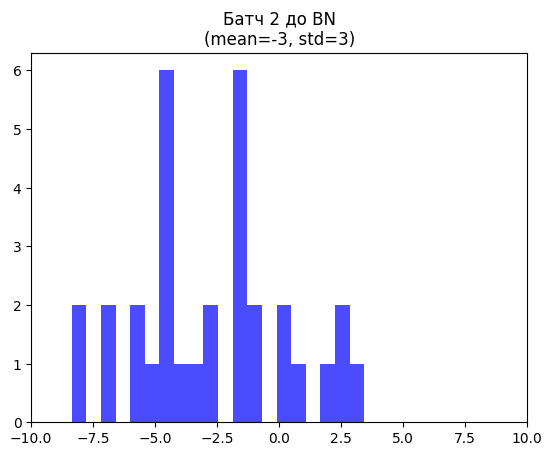

In [20]:
plt.hist(batch2[:, 0].detach().numpy(), bins=20, alpha=0.7, color='blue')
plt.title('Батч 2 до BN\n(mean=-3, std=3)')
plt.xlim(-10, 10)

(-4.0, 4.0)

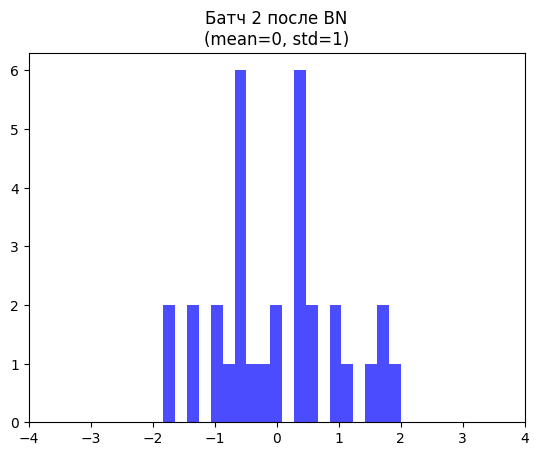

In [21]:
plt.hist(batch2_norm[:, 0].detach().numpy(), bins=20, alpha=0.7, color='blue')
plt.title('Батч 2 после BN\n(mean=0, std=1)')
plt.xlim(-4, 4)

(-10.0, 10.0)

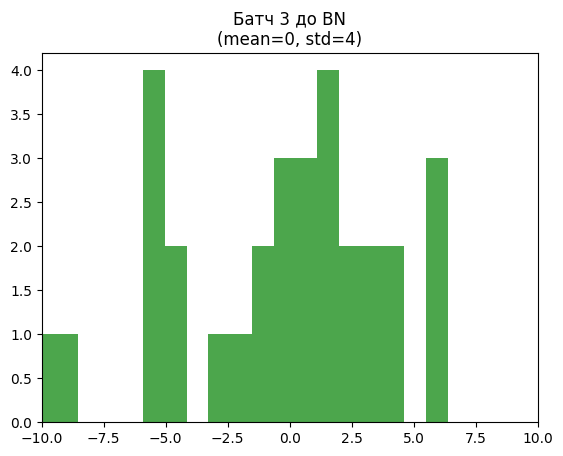

In [22]:
plt.hist(batch3[:, 0].detach().numpy(), bins=20, alpha=0.7, color='green')
plt.title('Батч 3 до BN\n(mean=0, std=4)')
plt.xlim(-10, 10)

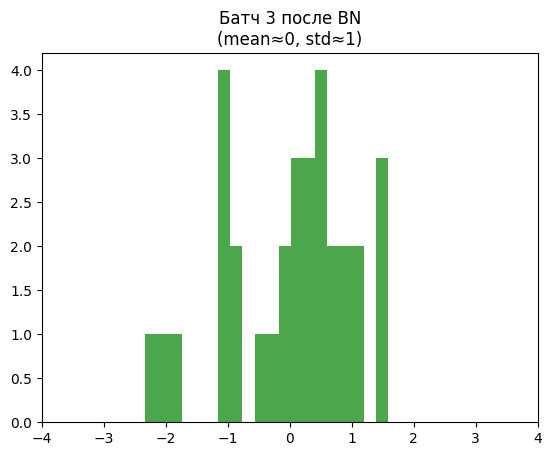

Running mean после train: [0.03178707 0.23322637 0.19357795]
Running var  после train: [4.012055  4.7174654 3.24229  ]

=== BatchNorm в режиме eval() ===
Среднее текущего eval-батча, feature 0: 19.098
Среднее выхода BN, feature 0:         9.519
eval использует running statistics: True


In [23]:
plt.hist(batch3_norm[:, 0].detach().numpy(), bins=20, alpha=0.7, color='green')
plt.title('Батч 3 после BN\n(mean≈0, std≈1)')
plt.xlim(-4, 4)
plt.show()

# В режиме train BatchNorm использовал статистики каждого текущего батча
# и одновременно обновил running_mean / running_var.
print('Running mean после train:', batchnorm.running_mean[:3].detach().numpy())
print('Running var  после train:', batchnorm.running_var[:3].detach().numpy())

# В режиме eval статистики текущего батча уже НЕ используются:
# слой нормализует вход накопленными running_mean/running_var.
batchnorm.eval()
eval_batch = torch.normal(20.0, 5.0, (32, 10))
with torch.no_grad():
    eval_norm = batchnorm(eval_batch)
    manual_eval = (
        (eval_batch - batchnorm.running_mean) /
        torch.sqrt(batchnorm.running_var + batchnorm.eps)
    ) * batchnorm.weight + batchnorm.bias

print('\n=== BatchNorm в режиме eval() ===')
print(f'Среднее текущего eval-батча, feature 0: {eval_batch[:, 0].mean().item():.3f}')
print(f'Среднее выхода BN, feature 0:         {eval_norm[:, 0].mean().item():.3f}')
print('eval использует running statistics:', torch.allclose(eval_norm, manual_eval, atol=1e-6))


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Расширьте класс `torch.nn.Linear`, описав класс `InitializedLinear` и добавив возможность инициализировать веса слоя при помощи функций из пакета `torch.nn.init` (инициализацию bias оставьте по умолчанию). Обратите внимание, что данные функции имеют дополнительные параметры. Данные параметры должны передаваться в момент создания объекта класса `InitializedLinear`.

Пример создания слоя:
```
InitializedLinear(n_features, n_hidden, init_f=nn.init.uniform_, init_args={"a": 0.0, "b": 1.0})
```

- [ ] Проверено на семинаре

In [24]:
class InitializedLinear(nn.Linear):
    def __init__(self, in_features, out_features, bias=True,
                 init_f=nn.init.xavier_uniform_, init_args=None):
        super().__init__(in_features, out_features, bias)
        self.init_f = init_f
        self.init_args = init_args or {}
        self.init_f(self.weight, **self.init_args)

In [25]:
layers = {
    'Uniform [0,1]': InitializedLinear(100, 50, init_f=nn.init.uniform_, init_args={"a": 0, "b": 1}),
    'Normal (0,1)': InitializedLinear(100, 50, init_f=nn.init.normal_, init_args={"mean": 0, "std": 1}),
    'Xavier': InitializedLinear(100, 50, init_f=nn.init.xavier_uniform_),
    'Kaiming': InitializedLinear(100, 50, init_f=nn.init.kaiming_normal_),
    'Constant (0.1)': InitializedLinear(100, 50, init_f=nn.init.constant_, init_args={"val": 0.1})
}

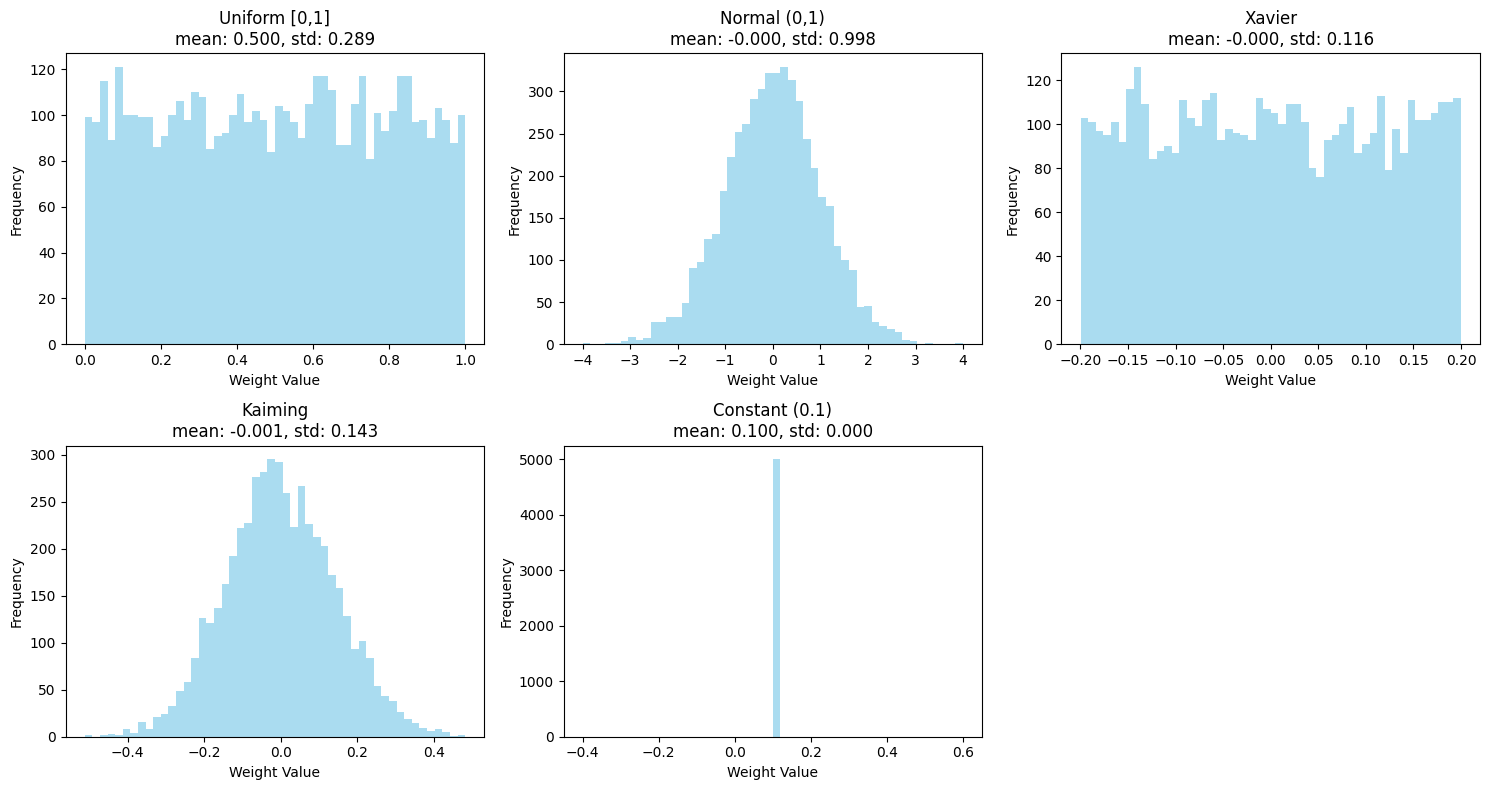

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (name, layer) in enumerate(layers.items()):
    weights = layer.weight.data.flatten().numpy()
    axes[i].hist(weights, bins=50, alpha=0.7, color='skyblue')
    axes[i].set_title(f'{name}\nmean: {weights.mean():.3f}, std: {weights.std():.3f}')
    axes[i].set_xlabel('Weight Value')
    axes[i].set_ylabel('Frequency')

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

In [27]:
layer = InitializedLinear(
    in_features=10,
    out_features=5,
    init_f=nn.init.uniform_,
    init_args={"a": 0.0, "b": 1.0}
)
print(f"Веса: {layer.weight.shape}")
print(f"Min: {layer.weight.min():.3f}, Max: {layer.weight.max():.3f}")

Веса: torch.Size([5, 10])
Min: 0.026, Max: 0.998


<p class="task" id="2"></p>

2\. Решите задачу регрессии несколько раз, изменяя способ инициализации весов. Рассмотрите следующие варианты:
* `nn.init.uniform_`
* `nn.init.normal_`
* `nn.init.constant_`
* `nn.xavier_uniform_`
* `nn.kaiming_uniform_`

Визуализируйте график изменения значений MSE с ходом эпох. Дайте кривым, соответствующие разным способам инициализации, различные цвета и добавьте подписи. Для улучшения читаемости графиков можно рассматривать области экстремальных значений отдельно.

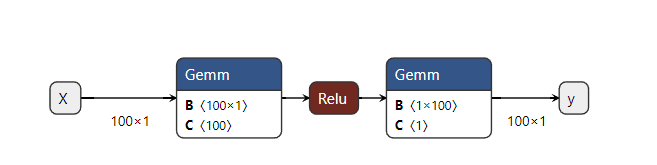

- [ ] Проверено на семинаре

In [28]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [29]:
class SimpleNet(nn.Module):
    def __init__(self, init_func=None, init_args=None):
        super().__init__()
        self.fc1 = nn.Linear(1, 100)
        self.fc2 = nn.Linear(100, 1)
        self.relu = nn.ReLU()

        if init_func is not None:
            init_func(self.fc1.weight, **init_args)
            init_func(self.fc2.weight, **init_args)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [30]:
init_methods = {
    'uniform': (init.uniform_, {'a': -1.0, 'b': 1.0}),
    'normal': (init.normal_, {'mean': 0.0, 'std': 1.0}),
    'constant': (init.constant_, {'val': 0.1}),
    'xavier_uniform': (init.xavier_uniform_, {'gain': 1.0}),
    'kaiming_uniform': (init.kaiming_uniform_, {'a': 0, 'mode': 'fan_in', 'nonlinearity': 'relu'})
}

In [31]:
results = {}
epochs = 1000

for name, (init_func, init_args) in init_methods.items():
    print(f"Обучение с инициализацией: {name}")

    model = SimpleNet(init_func, init_args)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    mse_history = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        mse_history.append(loss.item())

        if epoch % 200 == 0:
            print(f"  Epoch {epoch}, MSE: {loss.item():.6f}")

    results[name] = mse_history

Обучение с инициализацией: uniform
  Epoch 0, MSE: 16.252966
  Epoch 200, MSE: 0.086303
  Epoch 400, MSE: 0.037507
  Epoch 600, MSE: 0.016048
  Epoch 800, MSE: 0.007979
Обучение с инициализацией: normal
  Epoch 0, MSE: 11.083421
  Epoch 200, MSE: 0.013975
  Epoch 400, MSE: 0.003009
  Epoch 600, MSE: 0.001422
  Epoch 800, MSE: 0.001110
Обучение с инициализацией: constant
  Epoch 0, MSE: 8.755589
  Epoch 200, MSE: 0.327506
  Epoch 400, MSE: 0.168672
  Epoch 600, MSE: 0.167907
  Epoch 800, MSE: 0.166855
Обучение с инициализацией: xavier_uniform
  Epoch 0, MSE: 0.491102
  Epoch 200, MSE: 0.107813
  Epoch 400, MSE: 0.008624
  Epoch 600, MSE: 0.003364
  Epoch 800, MSE: 0.002255
Обучение с инициализацией: kaiming_uniform
  Epoch 0, MSE: 1.246633
  Epoch 200, MSE: 0.006273
  Epoch 400, MSE: 0.001239
  Epoch 600, MSE: 0.000911
  Epoch 800, MSE: 0.000884


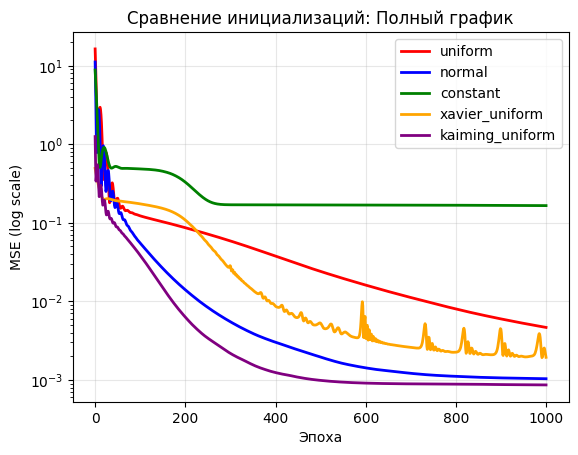

In [32]:
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, (name, mse_history) in enumerate(results.items()):
    plt.semilogy(mse_history, color=colors[i], label=name, linewidth=2)
plt.xlabel('Эпоха')
plt.ylabel('MSE (log scale)')
plt.title('Сравнение инициализаций: Полный график')
plt.legend()
plt.grid(True, alpha=0.3)

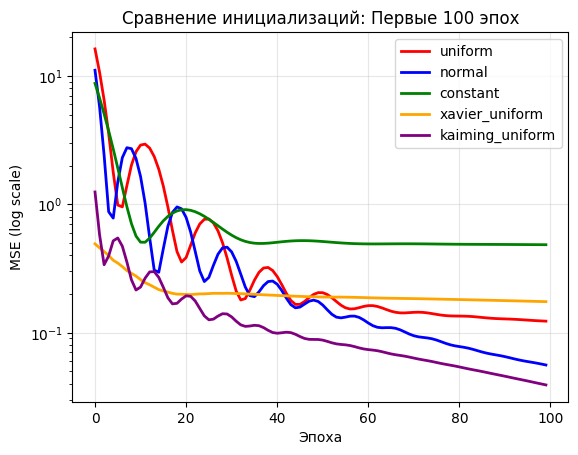

In [33]:
for i, (name, mse_history) in enumerate(results.items()):
    plt.semilogy(mse_history[:100], color=colors[i], label=name, linewidth=2)

plt.xlabel('Эпоха')
plt.ylabel('MSE (log scale)')
plt.title('Сравнение инициализаций: Первые 100 эпох')
plt.legend()
plt.grid(True, alpha=0.3)

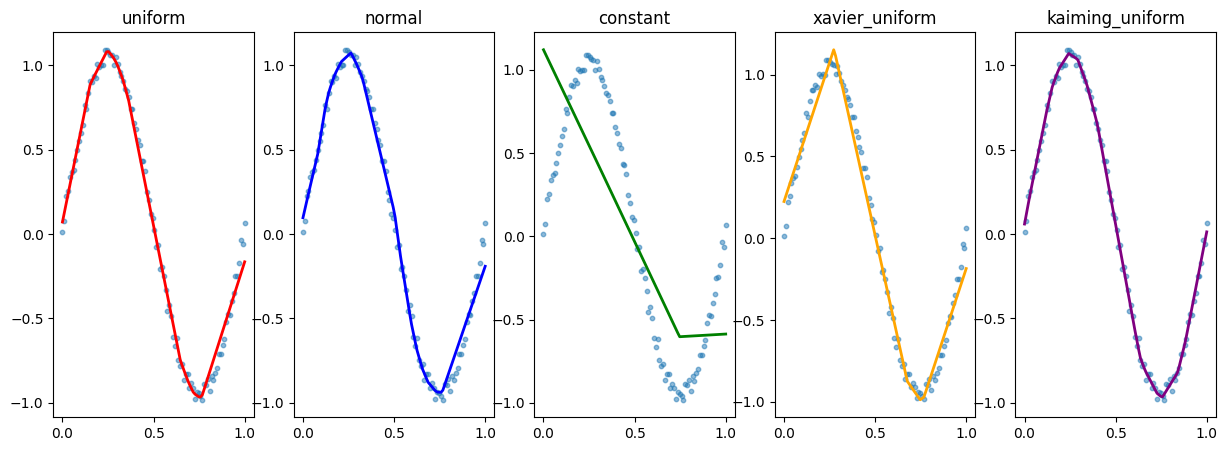

In [34]:
plt.figure(figsize=(15, 5))

for i, (name, _) in enumerate(init_methods.items()):
    model = SimpleNet(init_methods[name][0], init_methods[name][1])
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(500):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        pred = model(X)

    plt.subplot(1, len(init_methods), i+1)
    plt.scatter(X.numpy(), y.numpy(), alpha=0.5, s=10, label='Данные')
    plt.plot(X.numpy(), pred.numpy(), color=colors[i], linewidth=2, label='Предсказание')
    plt.title(f'{name}')

<p class="task" id="3"></p>

3\. Исследуйте, как добавление дропаута влияет на процесс обучения модели. Решите задачу регрессии несколько раз, изменяя значения вероятности дропаута $p$ от 0 до 0.8. В качестве модели рассмотрите нейронную сеть с одним скрытым слоем.

Визуализируйте график изменения значений $R^2$ в зависимости от вероятности дропаута $p$ на обучающей и тестовой выборке. Визуализируйте на отдельном графике зависимости разности между $R^2$ на обучающей выборки и $R^2$ на тестовой выборке.

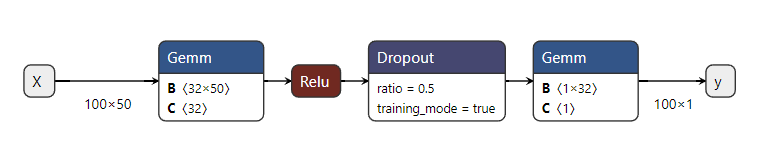

- [ ] Проверено на семинаре

In [35]:
from sklearn.datasets import make_regression
import torch as th

th.manual_seed(42)
X, y, coef = make_regression(
    n_samples=100,
    n_features=50,
    n_informative=20,
    noise=2,
    coef=True,
    random_state=42,

)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [37]:
class DropoutNet(nn.Module):
    def __init__(self, input_size=50, hidden_size=32, output_size=1, dropout_p=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [38]:
dropout_probs = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
train_r2_scores = []
test_r2_scores = []
difference_scores = []

epochs = 1000

for p in dropout_probs:
    print(f"Обучение с dropout p = {p}")

    model = DropoutNet(dropout_p=p)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        # Train mode
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

    # Оценка на train и test
    model.eval()
    with torch.no_grad():
        # Train R²
        train_pred = model(X_train)
        train_r2 = r2_score(y_train.numpy(), train_pred.numpy())
        train_r2_scores.append(train_r2)

        # Test R²
        test_pred = model(X_test)
        test_r2 = r2_score(y_test.numpy(), test_pred.numpy())
        test_r2_scores.append(test_r2)

        # Разность
        difference = train_r2 - test_r2
        difference_scores.append(difference)

    print(f"  Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}, Разность: {difference:.4f}")

Обучение с dropout p = 0.0
  Train R²: 1.0000, Test R²: 0.4366, Разность: 0.5634
Обучение с dropout p = 0.1
  Train R²: 0.9986, Test R²: 0.4862, Разность: 0.5124
Обучение с dropout p = 0.2
  Train R²: 0.9982, Test R²: 0.5287, Разность: 0.4695
Обучение с dropout p = 0.3
  Train R²: 0.9974, Test R²: 0.5537, Разность: 0.4437
Обучение с dropout p = 0.4
  Train R²: 0.9956, Test R²: 0.5627, Разность: 0.4328
Обучение с dropout p = 0.5
  Train R²: 0.9917, Test R²: 0.5916, Разность: 0.4001
Обучение с dropout p = 0.6
  Train R²: 0.9909, Test R²: 0.5802, Разность: 0.4107
Обучение с dropout p = 0.7
  Train R²: 0.9766, Test R²: 0.5719, Разность: 0.4047
Обучение с dropout p = 0.8
  Train R²: 0.9602, Test R²: 0.5418, Разность: 0.4185


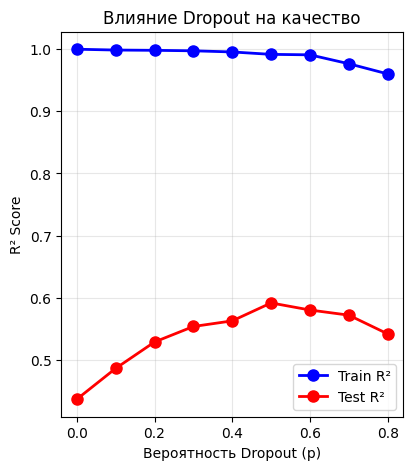

In [39]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(dropout_probs, train_r2_scores, 'o-', linewidth=2, markersize=8, label='Train R²', color='blue')
plt.plot(dropout_probs, test_r2_scores, 'o-', linewidth=2, markersize=8, label='Test R²', color='red')
plt.xlabel('Вероятность Dropout (p)')
plt.ylabel('R² Score')
plt.title('Влияние Dropout на качество')
plt.legend()
plt.grid(True, alpha=0.3)

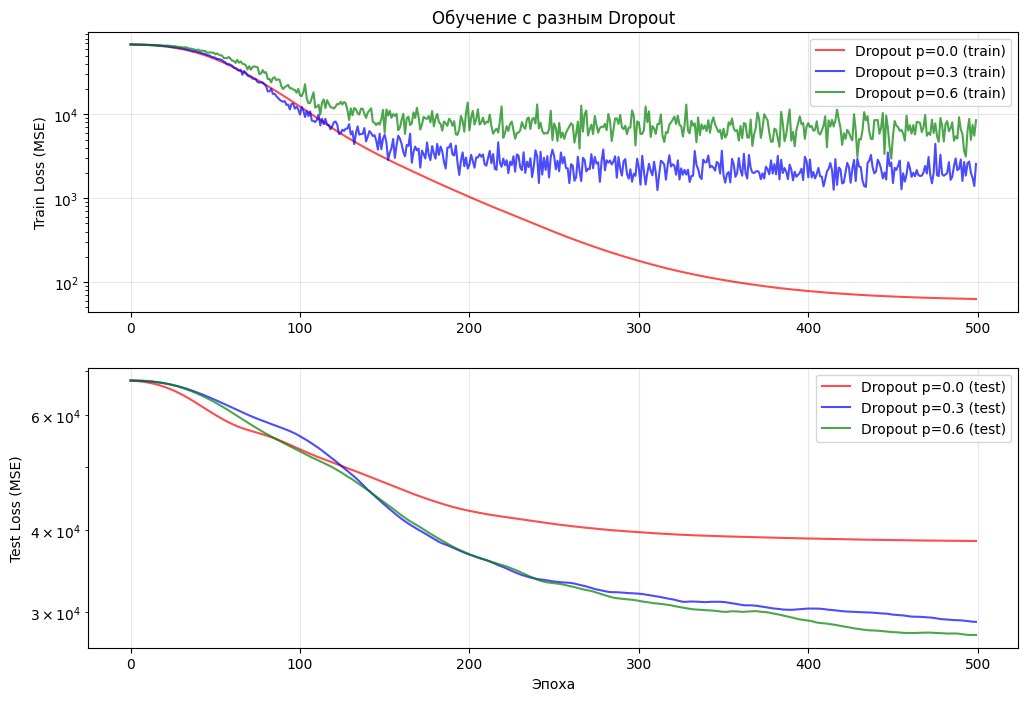

In [40]:
plt.figure(figsize=(12, 8))

selected_probs = [0.0, 0.3, 0.6]
colors = ['red', 'blue', 'green']

for i, p in enumerate(selected_probs):
    model = DropoutNet(dropout_p=p)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    train_losses = []
    test_losses = []

    for epoch in range(500):
        # Train
        model.train()
        optimizer.zero_grad()
        train_outputs = model(X_train)
        train_loss = criterion(train_outputs, y_train)
        train_loss.backward()
        optimizer.step()

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

    plt.subplot(2, 1, 1)
    plt.semilogy(train_losses, color=colors[i], alpha=0.7, label=f'Dropout p={p} (train)')
    plt.subplot(2, 1, 2)
    plt.semilogy(test_losses, color=colors[i], alpha=0.7, label=f'Dropout p={p} (test)')

plt.subplot(2, 1, 1)
plt.ylabel('Train Loss (MSE)')
plt.title('Обучение с разным Dropout')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.xlabel('Эпоха')
plt.ylabel('Test Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

<p class="task" id="4"></p>

4\. Решите задачу регрессии с- и без использования пакетной нормализации. Покажите, как меняется результат обучения моделей при различных значениях скорости обучения (0.001, 0.01, 0.1) за одно и то же количество эпох.

Визуализируйте график изменения значений $R^2$ в зависимости от эпохи при различных значениях скорости обучения с- и без использования пакетной нормализации.

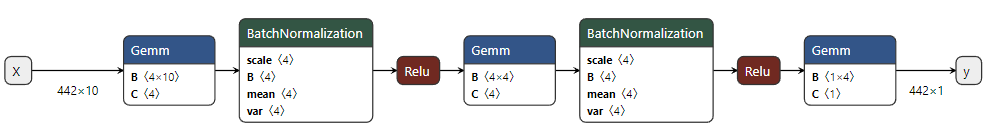

- [ ] Проверено на семинаре

In [41]:
from sklearn.datasets import load_diabetes

X_raw, y_raw = load_diabetes(return_X_y=True)


In [42]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42
)

# Все статистики масштабирования оцениваются только по train.
scaler_x_task4 = StandardScaler().fit(X_train_np)
y_mean_task4 = float(np.mean(y_train_np))
y_std_task4 = float(np.std(y_train_np))

X_train = th.FloatTensor(scaler_x_task4.transform(X_train_np))
X_test = th.FloatTensor(scaler_x_task4.transform(X_test_np))
y_train = th.FloatTensor(((y_train_np - y_mean_task4) / y_std_task4).reshape(-1, 1))
y_test = th.FloatTensor(((y_test_np - y_mean_task4) / y_std_task4).reshape(-1, 1))

print('Task 4 split:', X_train.shape, X_test.shape)
print('Масштабирование X и y рассчитано только по train.')


Task 4 split: torch.Size([309, 10]) torch.Size([133, 10])
Масштабирование X и y рассчитано только по train.


In [43]:
class NetWithBN(nn.Module):
    def __init__(self, input_size=10, hidden_size=4, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.fc2(x)
        return x

In [44]:
class NetWithoutBN(nn.Module):
    def __init__(self, input_size=10, hidden_size=4, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [45]:
learning_rates = [0.001, 0.01, 0.1]
epochs = 1000

results = {}

for lr in learning_rates:
    model_with_bn = NetWithBN()
    model_without_bn = NetWithoutBN()
    optimizer_bn = torch.optim.Adam(model_with_bn.parameters(), lr=lr)
    optimizer_no_bn = torch.optim.Adam(model_without_bn.parameters(), lr=lr)

    criterion = nn.MSELoss()

    r2_bn_train, r2_bn_test = [], []
    r2_no_bn_train, r2_no_bn_test = [], []

    for epoch in range(epochs):
        # Обучение с BatchNorm
        model_with_bn.train()
        optimizer_bn.zero_grad()
        outputs_bn = model_with_bn(X_train)
        loss_bn = criterion(outputs_bn, y_train)
        loss_bn.backward()
        optimizer_bn.step()

        # Обучение без BatchNorm
        model_without_bn.train()
        optimizer_no_bn.zero_grad()
        outputs_no_bn = model_without_bn(X_train)
        loss_no_bn = criterion(outputs_no_bn, y_train)
        loss_no_bn.backward()
        optimizer_no_bn.step()

        if epoch % 50 == 0:
            model_with_bn.eval()
            model_without_bn.eval()

            with torch.no_grad():
                # BatchNorm
                train_pred_bn = model_with_bn(X_train)
                test_pred_bn = model_with_bn(X_test)
                r2_bn_train.append(r2_score(y_train.numpy(), train_pred_bn.numpy()))
                r2_bn_test.append(r2_score(y_test.numpy(), test_pred_bn.numpy()))

                # Без BatchNorm
                train_pred_no_bn = model_without_bn(X_train)
                test_pred_no_bn = model_without_bn(X_test)
                r2_no_bn_train.append(r2_score(y_train.numpy(), train_pred_no_bn.numpy()))
                r2_no_bn_test.append(r2_score(y_test.numpy(), test_pred_no_bn.numpy()))

    results[lr] = {
        'bn_train': r2_bn_train,
        'bn_test': r2_bn_test,
        'no_bn_train': r2_no_bn_train,
        'no_bn_test': r2_no_bn_test
    }

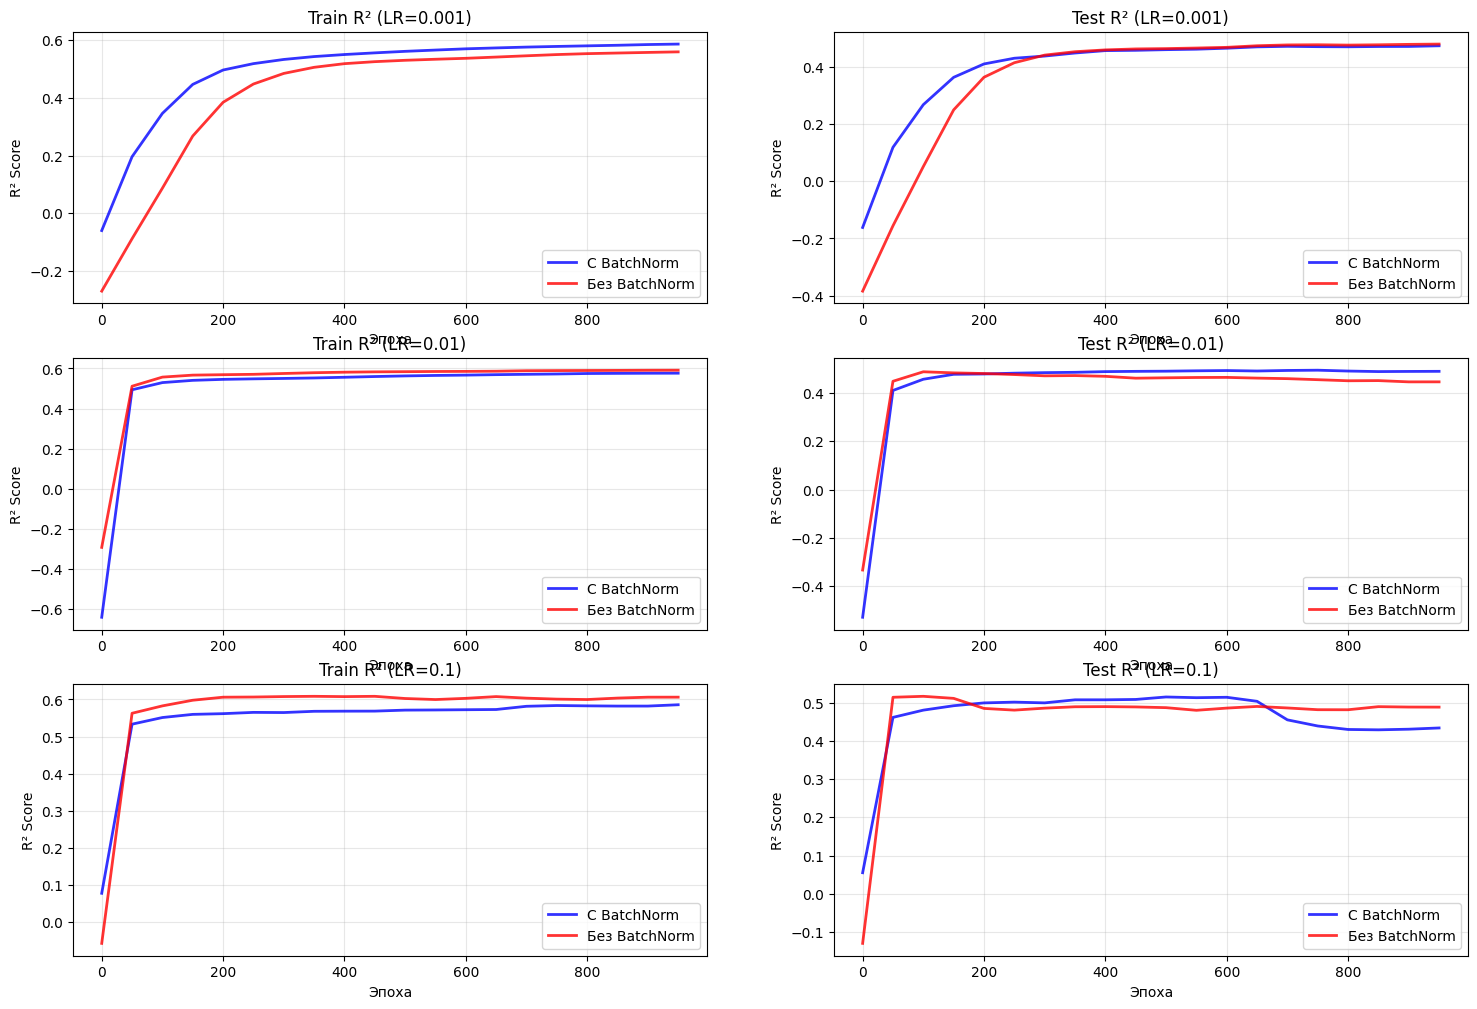

In [46]:
epoch_points = list(range(0, epochs, 50))

plt.figure(figsize=(18, 12))

for i, lr in enumerate(learning_rates):
    # Train R²
    plt.subplot(3, 2, 2*i+1)
    plt.plot(epoch_points, results[lr]['bn_train'], 'b-', linewidth=2, label='С BatchNorm', alpha=0.8)
    plt.plot(epoch_points, results[lr]['no_bn_train'], 'r-', linewidth=2, label='Без BatchNorm', alpha=0.8)
    plt.title(f'Train R² (LR={lr})')
    plt.xlabel('Эпоха')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Test R²
    plt.subplot(3, 2, 2*i+2)
    plt.plot(epoch_points, results[lr]['bn_test'], 'b-', linewidth=2, label='С BatchNorm', alpha=0.8)
    plt.plot(epoch_points, results[lr]['no_bn_test'], 'r-', linewidth=2, label='Без BatchNorm', alpha=0.8)
    plt.title(f'Test R² (LR={lr})')
    plt.xlabel('Эпоха')
    plt.ylabel('R² Score')
    plt.legend()
    plt.grid(True, alpha=0.3)

In [47]:
plt.figure(figsize=(15, 5))

final_train_bn = [results[lr]['bn_train'][-1] for lr in learning_rates]
final_test_bn = [results[lr]['bn_test'][-1] for lr in learning_rates]
final_train_no_bn = [results[lr]['no_bn_train'][-1] for lr in learning_rates]
final_test_no_bn = [results[lr]['no_bn_test'][-1] for lr in learning_rates]
print("\n" + "="*60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ R² ПОСЛЕ 1000 ЭПОХ:")
print("="*60)

for lr in learning_rates:
    bn_train_final = results[lr]['bn_train'][-1]
    bn_test_final = results[lr]['bn_test'][-1]
    no_bn_train_final = results[lr]['no_bn_train'][-1]
    no_bn_test_final = results[lr]['no_bn_test'][-1]

    print(f"\nLearning Rate = {lr}:")
    print(f"  С BatchNorm:    Train R² = {bn_train_final:.4f}, Test R² = {bn_test_final:.4f}")
    print(f"  Без BatchNorm:  Train R² = {no_bn_train_final:.4f}, Test R² = {no_bn_test_final:.4f}")


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ R² ПОСЛЕ 1000 ЭПОХ:

Learning Rate = 0.001:
  С BatchNorm:    Train R² = 0.5867, Test R² = 0.4750
  Без BatchNorm:  Train R² = 0.5598, Test R² = 0.4809

Learning Rate = 0.01:
  С BatchNorm:    Train R² = 0.5762, Test R² = 0.4907
  Без BatchNorm:  Train R² = 0.5911, Test R² = 0.4470

Learning Rate = 0.1:
  С BatchNorm:    Train R² = 0.5856, Test R² = 0.4341
  Без BatchNorm:  Train R² = 0.6061, Test R² = 0.4887


<Figure size 1500x500 with 0 Axes>

<p class="task" id="5"></p>

5\. Решите задачу регрессии c использованием различных алгоритмов градиентного спуска. Покажите, как меняется результат обучения моделей при использовании различных алгоритмов (Adam, Adagram, RMSProp, SGD) за одно и то же количество эпох с одной и той же скоростью обучения. Используйте модель с архитектурой, аналогичной модели из предыдущей задачи.

Визуализируйте график изменения значений MAPE в зависимости от эпохи при использовании различных алгоритмов градиентного спуска.

- [ ] Проверено на семинаре

In [48]:
def load_boston():
    """
    Надёжная загрузка Boston Housing без устаревшего sklearn.load_boston().

    Порядок источников:
    1) локальный файл рядом с ноутбуком (если есть);
    2) OpenML, dataset_id=531;
    3) исходный датасет CMU по HTTPS.

    Возвращает
    ---------
    X : np.ndarray, shape (506, 13)
    y : np.ndarray, shape (506,)
    """
    from pathlib import Path
    import numpy as np
    import pandas as pd

    local_candidates = [
        Path("boston.csv"),
        Path("BostonHousing.csv"),
        Path("boston_housing.csv"),
        Path("housing.data"),
        Path("data/boston.csv"),
        Path("data/BostonHousing.csv"),
        Path("data/housing.data"),
    ]

    for path in local_candidates:
        if not path.exists():
            continue

        try:
            if path.suffix.lower() == ".csv":
                df = pd.read_csv(path)

                target_name = next(
                    (c for c in ["MEDV", "medv", "target", "PRICE", "price"]
                     if c in df.columns),
                    None,
                )

                if target_name is not None:
                    y = df[target_name].to_numpy(dtype=np.float32)
                    X = df.drop(columns=[target_name]).to_numpy(dtype=np.float32)
                elif df.shape[1] >= 14:
                    X = df.iloc[:, :13].to_numpy(dtype=np.float32)
                    y = df.iloc[:, 13].to_numpy(dtype=np.float32)
                else:
                    raise ValueError(
                        f"В {path} ожидалось минимум 14 столбцов "
                        "или столбец MEDV/target."
                    )
            else:
                df = pd.read_csv(path, sep=r"\s+", header=None)
                if df.shape[1] < 14:
                    raise ValueError(
                        f"В {path} ожидалось минимум 14 столбцов, "
                        f"получено {df.shape[1]}."
                    )
                X = df.iloc[:, :13].to_numpy(dtype=np.float32)
                y = df.iloc[:, 13].to_numpy(dtype=np.float32)

            print(f"Boston Housing загружен из локального файла: {path}")
            return X, y
        except Exception as exc:
            print(f"Локальный файл {path} найден, но не прочитан: {exc}")

    openml_error = None
    try:
        from sklearn.datasets import fetch_openml

        X, y = fetch_openml(
            data_id=531,       # Boston Housing
            as_frame=False,
            return_X_y=True,
        )
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        print("Boston Housing загружен через sklearn.fetch_openml(data_id=531).")
        return X, y
    except Exception as exc:
        openml_error = exc
        print(f"OpenML недоступен: {type(exc).__name__}: {exc}")

    cmu_error = None
    try:
        data_url = "https://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(
            data_url,
            sep=r"\s+",
            skiprows=22,
            header=None,
        )
        X = np.hstack([
            raw_df.values[::2, :],
            raw_df.values[1::2, :2],
        ]).astype(np.float32)
        y = raw_df.values[1::2, 2].astype(np.float32)

        print("Boston Housing загружен с HTTPS-источника CMU.")
        return X, y
    except Exception as exc:
        cmu_error = exc

    raise RuntimeError(
        "Не удалось загрузить Boston Housing.\n"
        "Проверены: локальный файл, OpenML (data_id=531) и CMU HTTPS.\n"
        "Для полностью офлайн-запуска положите рядом с ноутбуком "
        "файл housing.data или BostonHousing.csv.\n"
        f"OpenML: {type(openml_error).__name__}: {openml_error}\n"
        f"CMU: {type(cmu_error).__name__}: {cmu_error}"
    )


In [49]:
X_boston_raw, y_boston_raw = load_boston()
print('Boston Housing:', X_boston_raw.shape, y_boston_raw.shape)
print('Диапазон target в исходном масштабе:',
      float(y_boston_raw.min()), '...', float(y_boston_raw.max()))


Boston Housing загружен через sklearn.fetch_openml(data_id=531).
Boston Housing: (506, 13) (506,)
Диапазон target в исходном масштабе: 5.0 ... 50.0


In [50]:
class RegressionNet(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden1_size)
        self.bn1 = nn.BatchNorm1d(hidden1_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1_size, hidden2_size)
        self.bn2 = nn.BatchNorm1d(hidden2_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

In [51]:
def calculate_mape(model, X_scaled, y_scaled, scaler_y):
    """MAPE в ИСХОДНОМ масштабе target, а не в стандартизованном пространстве."""
    model.eval()
    with th.no_grad():
        y_pred_scaled = model(X_scaled).cpu().numpy().reshape(-1, 1)
        y_true_scaled = y_scaled.cpu().numpy().reshape(-1, 1)

    y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()
    y_true = scaler_y.inverse_transform(y_true_scaled).ravel()

    # Boston Housing имеет строго положительный target. epsilon только защищает от деления на 0.
    epsilon = 1e-8
    return float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100)


In [52]:
def train_model_with_optimizer(optimizer_name, model, X_train, y_train, X_test, y_test,
                               scaler_y, learning_rate=0.01, n_epochs=1000):
    """Обучает модель и возвращает MAPE, рассчитанный в исходном масштабе target."""
    criterion = nn.MSELoss()

    if optimizer_name == 'Adam':
        optimizer = th.optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'Adagrad':
        optimizer = th.optim.Adagrad(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'RMSprop':
        optimizer = th.optim.RMSprop(model.parameters(), lr=learning_rate)
    elif optimizer_name == 'SGD':
        optimizer = th.optim.SGD(model.parameters(), lr=learning_rate)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    train_mape_history = []
    test_mape_history = []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(X_train)
        loss = criterion(y_pred_train, y_train)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 20 == 0:
            train_mape_history.append(calculate_mape(model, X_train, y_train, scaler_y))
            test_mape_history.append(calculate_mape(model, X_test, y_test, scaler_y))

    return train_mape_history, test_mape_history


In [53]:
def visualize_optimizer_results(results, optimizers, n_epochs):
    """Визуализирует MAPE в исходном масштабе Boston Housing."""
    epochs_plot = list(range(20, n_epochs + 1, 20))
    colors = ['blue', 'green', 'red', 'orange', 'purple']

    fig, ax = plt.subplots(figsize=(10, 5))
    for i, optimizer_name in enumerate(optimizers):
        ax.plot(
            epochs_plot,
            results[optimizer_name]['test_mape'],
            color=colors[i], linewidth=2, label=optimizer_name
        )
    ax.set_title('Test MAPE для различных оптимизаторов')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('MAPE (%)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    final_train_mape = [results[opt]['train_mape'][-1] for opt in optimizers]
    final_test_mape = [results[opt]['test_mape'][-1] for opt in optimizers]

    x_pos = np.arange(len(optimizers))
    width = 0.35
    fig, ax2 = plt.subplots(figsize=(9, 5))
    bars1 = ax2.bar(x_pos - width/2, final_train_mape, width,
                    label='Train MAPE', alpha=0.7)
    bars2 = ax2.bar(x_pos + width/2, final_test_mape, width,
                    label='Test MAPE', alpha=0.7)
    ax2.set_title('Финальные MAPE')
    ax2.set_xlabel('Оптимизатор')
    ax2.set_ylabel('MAPE (%)')
    ax2.set_xticks(x_pos, optimizers)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    for bar, value in zip(bars1, final_train_mape):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
    for bar, value in zip(bars2, final_test_mape):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print('\n' + '='*60)
    print('СТАТИСТИЧЕСКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ')
    print('='*60)
    for optimizer_name, final_train, final_test in zip(
        optimizers, final_train_mape, final_test_mape
    ):
        print(f'\n{optimizer_name}:')
        print(f'  Final Train MAPE: {final_train:.2f}%')
        print(f'  Final Test MAPE:  {final_test:.2f}%')
        print(f'  Разница:          {final_test - final_train:+.2f}%')


Boston Housing загружен через sklearn.fetch_openml(data_id=531).
BOSTON HOUSING DATASET:
Обучающая выборка: torch.Size([354, 13])
Тестовая выборка:   torch.Size([152, 13])
Признаков: 13
Scaler fit выполнен только на train.
--------------------------------------------------
СРАВНЕНИЕ АЛГОРИТМОВ ОПТИМИЗАЦИИ:

Обучение с оптимизатором: Adam
  Final Train MAPE: 6.13%
  Final Test MAPE:  13.67%

Обучение с оптимизатором: Adagrad
  Final Train MAPE: 8.91%
  Final Test MAPE:  12.53%

Обучение с оптимизатором: RMSprop
  Final Train MAPE: 7.08%
  Final Test MAPE:  13.35%

Обучение с оптимизатором: SGD
  Final Train MAPE: 9.83%
  Final Test MAPE:  12.55%


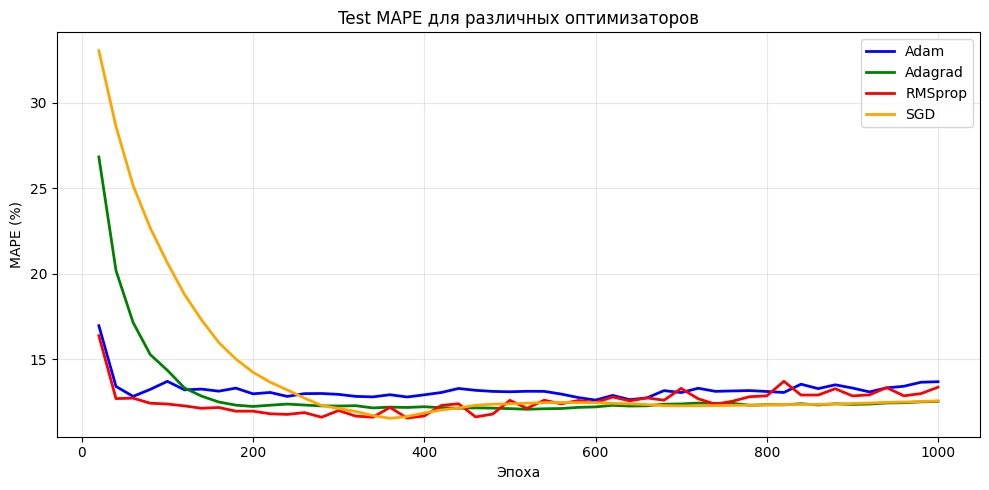

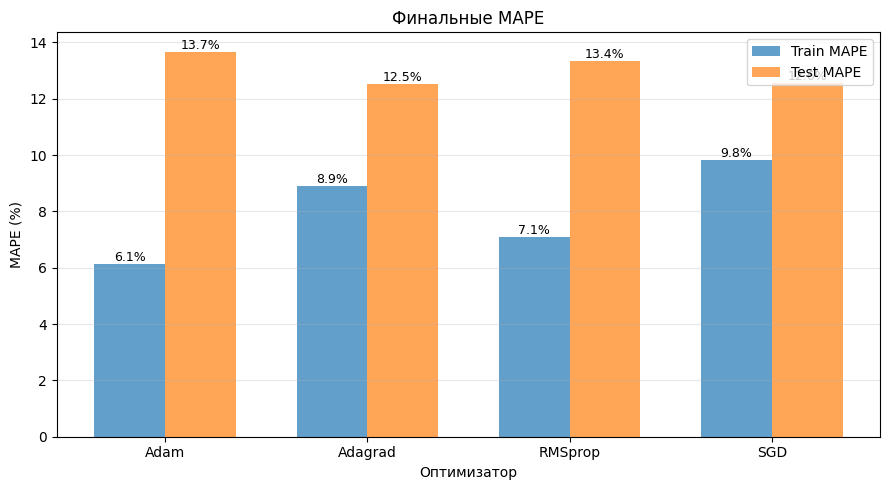


СТАТИСТИЧЕСКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ

Adam:
  Final Train MAPE: 6.13%
  Final Test MAPE:  13.67%
  Разница:          +7.55%

Adagrad:
  Final Train MAPE: 8.91%
  Final Test MAPE:  12.53%
  Разница:          +3.61%

RMSprop:
  Final Train MAPE: 7.08%
  Final Test MAPE:  13.35%
  Разница:          +6.28%

SGD:
  Final Train MAPE: 9.83%
  Final Test MAPE:  12.55%
  Разница:          +2.72%


In [54]:
X_raw, y_raw = load_boston()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.3, random_state=42
)
scaler_x = StandardScaler().fit(X_train_raw)
scaler_y = StandardScaler().fit(y_train_raw.reshape(-1, 1))

X_train = th.FloatTensor(scaler_x.transform(X_train_raw))
X_test = th.FloatTensor(scaler_x.transform(X_test_raw))
y_train = th.FloatTensor(scaler_y.transform(y_train_raw.reshape(-1, 1)))
y_test = th.FloatTensor(scaler_y.transform(y_test_raw.reshape(-1, 1)))

print('BOSTON HOUSING DATASET:')
print(f'Обучающая выборка: {X_train.shape}')
print(f'Тестовая выборка:   {X_test.shape}')
print(f'Признаков: {X_train.shape[1]}')
print('Scaler fit выполнен только на train.')
print('-' * 50)

learning_rate = 0.01
n_epochs = 1000
optimizers = ['Adam', 'Adagrad', 'RMSprop', 'SGD']

input_size = X_train.shape[1]
hidden1_size = 10
hidden2_size = 4
output_size = 1

th.manual_seed(42)
base_model = RegressionNet(input_size, hidden1_size, hidden2_size, output_size)
base_state = copy.deepcopy(base_model.state_dict())

results = {}
print('СРАВНЕНИЕ АЛГОРИТМОВ ОПТИМИЗАЦИИ:')
print('=' * 60)

for optimizer_name in optimizers:
    print(f'\nОбучение с оптимизатором: {optimizer_name}')
    model = RegressionNet(input_size, hidden1_size, hidden2_size, output_size)
    model.load_state_dict(base_state)

    train_mape, test_mape = train_model_with_optimizer(
        optimizer_name, model,
        X_train, y_train, X_test, y_test,
        scaler_y=scaler_y,
        learning_rate=learning_rate,
        n_epochs=n_epochs,
    )

    results[optimizer_name] = {
        'train_mape': train_mape,
        'test_mape': test_mape,
    }
    print(f'  Final Train MAPE: {train_mape[-1]:.2f}%')
    print(f'  Final Test MAPE:  {test_mape[-1]:.2f}%')

visualize_optimizer_results(results, optimizers, n_epochs)

<p class="task" id="6"></p>

6\. Решите задачу регрессии c использованием ранней остановки. Разбейте набор данных на обучающую и валидационную выборку в соотношении 80 на 20. Остановите процесс обучения, если целевая метрика (MAPE) не уменьшалась в течении последних $k$ ($k$ - гиперпараметр метода) эпох. В момент остановки выведите сообщение с текущим номером эпохи.

- [ ] Проверено на семинаре

In [57]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_mape = float('inf')
        self.best_epoch = 0
        self.best_state = None
        self.early_stop = False

    def __call__(self, val_mape, model, epoch):
        if val_mape < self.best_mape - self.min_delta:
            self.best_mape = float(val_mape)
            self.best_epoch = int(epoch)
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [58]:
class SimpleNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 10),
            nn.ReLU(),
            nn.Linear(10, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.net(x)

In [59]:
def calculate_mape(model, X_scaled, y_scaled, scaler_y):
    """MAPE в исходном масштабе target."""
    model.eval()
    with th.no_grad():
        pred_scaled = model(X_scaled).cpu().numpy().reshape(-1, 1)
        true_scaled = y_scaled.cpu().numpy().reshape(-1, 1)
    pred = scaler_y.inverse_transform(pred_scaled).ravel()
    true = scaler_y.inverse_transform(true_scaled).ravel()
    return float(np.mean(np.abs((true - pred) / (np.abs(true) + 1e-8))) * 100)


In [60]:
X_raw, y_raw = load_boston()
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

scaler_x_es = StandardScaler().fit(X_train_raw)
scaler_y_es = StandardScaler().fit(y_train_raw.reshape(-1, 1))

X_train = th.FloatTensor(scaler_x_es.transform(X_train_raw))
X_val = th.FloatTensor(scaler_x_es.transform(X_val_raw))
y_train = th.FloatTensor(scaler_y_es.transform(y_train_raw.reshape(-1, 1)))
y_val = th.FloatTensor(scaler_y_es.transform(y_val_raw.reshape(-1, 1)))

print('Train / validation:', X_train.shape, X_val.shape)
print('Доля validation:', len(X_val) / (len(X_train) + len(X_val)))
print('Scaler fit выполнен только на train.')


Boston Housing загружен через sklearn.fetch_openml(data_id=531).
Train / validation: torch.Size([404, 13]) torch.Size([102, 13])
Доля validation: 0.2015810276679842
Scaler fit выполнен только на train.


In [61]:
th.manual_seed(42)
model = SimpleNet(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = th.optim.Adam(model.parameters(), lr=0.01)


In [62]:
# Ранняя остановка по MAPE в исходном масштабе target.
patience = 10
early_stopping = EarlyStopping(patience=patience)
train_mape_history = []
val_mape_history = []
stop_epoch = None

for epoch in range(1, 1001):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    train_mape = calculate_mape(model, X_train, y_train, scaler_y_es)
    val_mape = calculate_mape(model, X_val, y_val, scaler_y_es)
    train_mape_history.append(train_mape)
    val_mape_history.append(val_mape)

    early_stopping(val_mape, model, epoch)

    if epoch == 1 or epoch % 50 == 0:
        print(f'Эпоха {epoch:4d}: Train MAPE={train_mape:.2f}%, Val MAPE={val_mape:.2f}%')

    if early_stopping.early_stop:
        stop_epoch = epoch
        print(f'Ранняя остановка на эпохе {epoch}: Val MAPE не улучшалась {patience} эпох.')
        print(f'Лучшая эпоха: {early_stopping.best_epoch}, лучшая Val MAPE: {early_stopping.best_mape:.2f}%')
        break

if stop_epoch is None:
    stop_epoch = len(train_mape_history)
    print(f'Достигнут лимит эпох: {stop_epoch}')

if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

best_train_mape = calculate_mape(model, X_train, y_train, scaler_y_es)
best_val_mape = calculate_mape(model, X_val, y_val, scaler_y_es)


Эпоха    1: Train MAPE=36.24%, Val MAPE=36.93%
Эпоха   50: Train MAPE=14.55%, Val MAPE=14.18%
Ранняя остановка на эпохе 78: Val MAPE не улучшалась 10 эпох.
Лучшая эпоха: 68, лучшая Val MAPE: 12.43%


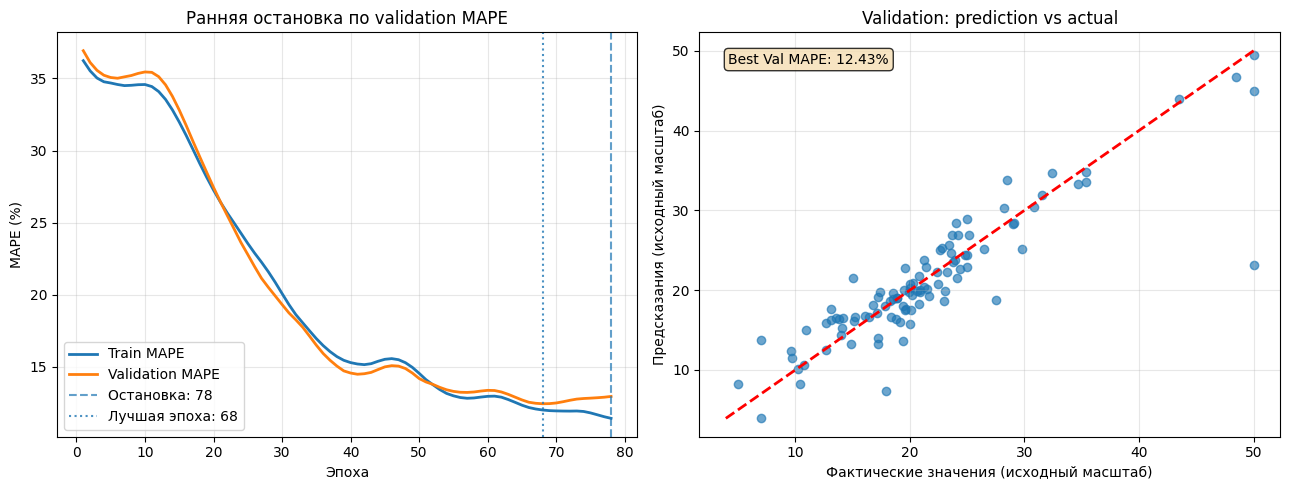


Результаты лучшего checkpoint:
Остановлено на эпохе: 78
Лучшая эпоха:         68
Train MAPE:           12.00%
Validation MAPE:      12.43%


In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_axis = np.arange(1, len(train_mape_history) + 1)
ax1.plot(epochs_axis, train_mape_history, label='Train MAPE', linewidth=2)
ax1.plot(epochs_axis, val_mape_history, label='Validation MAPE', linewidth=2)
ax1.axvline(stop_epoch, linestyle='--', alpha=0.7, label=f'Остановка: {stop_epoch}')
ax1.axvline(early_stopping.best_epoch, linestyle=':', alpha=0.8,
            label=f'Лучшая эпоха: {early_stopping.best_epoch}')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('MAPE (%)')
ax1.set_title('Ранняя остановка по validation MAPE')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scatter в исходном масштабе цены.
model.eval()
with th.no_grad():
    y_pred_val_scaled = model(X_val).cpu().numpy().reshape(-1, 1)
y_pred = scaler_y_es.inverse_transform(y_pred_val_scaled).ravel()
y_true = scaler_y_es.inverse_transform(y_val.cpu().numpy().reshape(-1, 1)).ravel()

ax2.scatter(y_true, y_pred, alpha=0.65)
lo = min(y_true.min(), y_pred.min())
hi = max(y_true.max(), y_pred.max())
ax2.plot([lo, hi], [lo, hi], 'r--', linewidth=2)
ax2.set_xlabel('Фактические значения (исходный масштаб)')
ax2.set_ylabel('Предсказания (исходный масштаб)')
ax2.set_title('Validation: prediction vs actual')
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, f'Best Val MAPE: {best_val_mape:.2f}%',
         transform=ax2.transAxes, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print('\nРезультаты лучшего checkpoint:')
print(f'Остановлено на эпохе: {stop_epoch}')
print(f'Лучшая эпоха:         {early_stopping.best_epoch}')
print(f'Train MAPE:           {best_train_mape:.2f}%')
print(f'Validation MAPE:      {best_val_mape:.2f}%')


## Обратная связь
- [ ] Хочу получить обратную связь по решению